<p>Python for Civil Engineers: Plotting Shear Force & Bending Moment Diagrams</p>
<img src="https://lh3.googleusercontent.com/d/1QQ5VEUcVlqQar9PYrs07iIaw5W02BoB6" width="400" />

<p>Reaction Calculation</p>

$$
L = 2+2+2 = 6\text{ m}
$$ 

$$
\sum M_A = 0
$$

$$
\implies R_D(6) - 1[2(50)] - 5[2(20)] = 0
$$

$$
\boxed{R_D = 50\text{ KN}}
$$

$$
\sum M_D = 0
$$

$$
\implies R_A(6) - 5[2(50)] - 1[2(20)] = 0
$$

$$
\boxed{R_A = 90\text{ KN}}
$$

In [3]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [6]:
Adist = []
Asf = []
Abm = []

def sf_bm():
    # Distance & load
    L = 6 # m
    RA = 90 # kN
    RD = 50 # kN

    for i in np.linspace(0, L, L+1, dtype=int):
        Adist.append(i)

        # Shear Force
        if i <= 2:
            sf = RA - 50*i
        elif i <= 4:
            sf = RA - 50*2
        else:
            sf = RA - 50*2 - 20*(i-4)
        Asf.append(sf)

        # Bending Moment
        if i <= 2:
            bm = RA*i -50*(i**2)/2
        elif i <= 4:
            bm = RA*i - 50*2*(i-1)
        else:
            bm = RA*i - 50*2*(i-1) - 20*((i-4)**2)/2
        Abm.append(bm)

    return Adist, Asf, Abm

result = sf_bm()

print("Distance (m):", result[0])
print("Shear Force (kN):", result[1])
print("Bending Moment (kNm):", result[2])
        

Distance (m): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Shear Force (kN): [np.int64(90), np.int64(40), np.int64(-10), -10, -10, np.int64(-30), np.int64(-50)]
Bending Moment (kNm): [np.float64(0.0), np.float64(65.0), np.float64(80.0), np.int64(70), np.int64(60), np.float64(40.0), np.float64(0.0)]


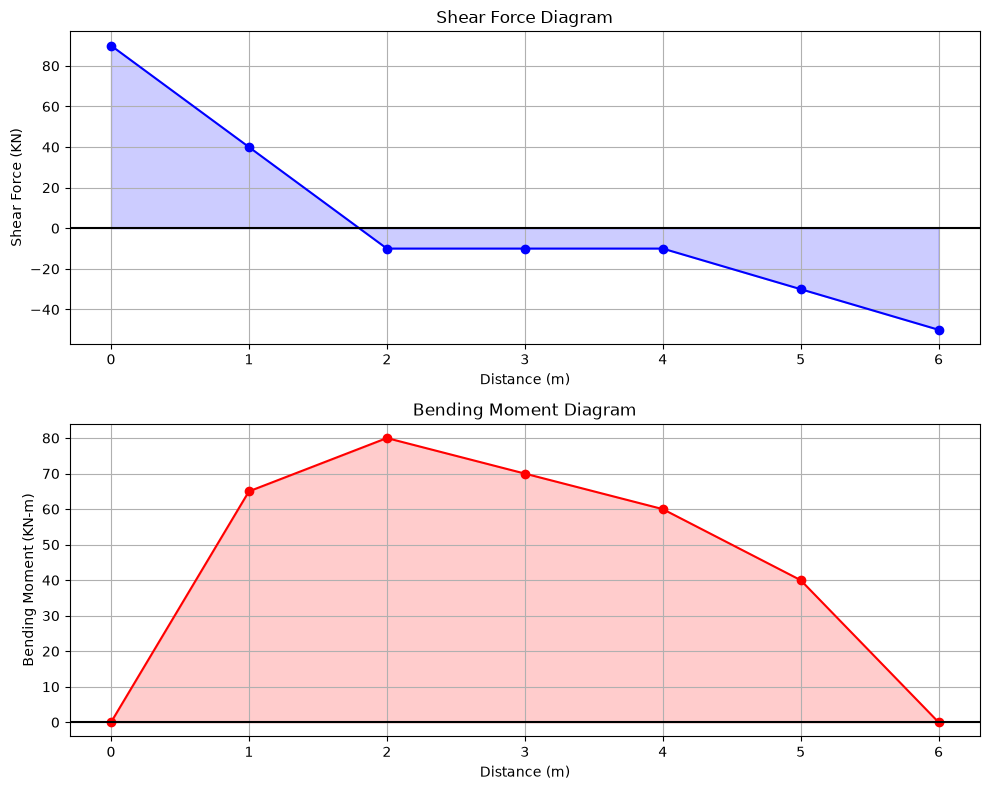

In [11]:
plt.figure(figsize=(10,8))

# SFD
plt.subplot(2,1,1)
plt.plot(Adist, Asf, color = 'blue', marker = 'o')
plt.fill_between(Adist, Asf, 0, color = 'blue', alpha = 0.2)
plt.axhline(0, color = 'black')
plt.xlabel("Distance (m)")
plt.ylabel("Shear Force (KN)")
plt.title("Shear Force Diagram")
plt.grid(True)

# BMD
plt.subplot(2,1,2)
plt.plot(Adist, Abm, color = 'red', marker = 'o')
plt.fill_between(Adist, Abm, 0, color = 'red', alpha = 0.2)
plt.axhline(0, color = 'black')
plt.xlabel("Distance (m)")
plt.ylabel("Bending Moment (KN-m)")
plt.title("Bending Moment Diagram")
plt.grid(True)

plt.tight_layout()
plt.show()
